# TRIX — a quantitative teardown
### Triple-smoothed EMA oscillator · daily bars · zero-line & signal-line cross · HAC inference · hold-period & parameter sweeps · Bonferroni correction

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Triple--smoothing_lag%3F: Confirmed_lag,_no_edge](https://img.shields.io/badge/Triple--smoothing_lag%3F-Confirmed_lag,_no_edge-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.*  We test whether TRIX(15) zero-line and signal-line crosses beat a random-direction control on daily bars across five liquid instruments, sweep holding windows and TRIX periods, apply Bonferroni correction over four period variants, and confirm the engine via a synthetic positive-control tape.

> **Not investment advice.**  Real data: Yahoo daily bars, 15-year window, as-of 2026-06-15; offline core runs on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> Plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from trix import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_zero(hold=20, cost=0.0, seed=None):
    """Pool zero-line cross trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        tx = st.trix(b["close"], period=15)
        entries = st.zero_line_entries(tx)
        dirs = st.random_directions(len(entries), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, entries, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

def pool_signal(hold=10, cost=0.0, seed=None):
    """Pool signal-line cross trades across the basket."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        tx = st.trix(b["close"], period=15)
        sig = st.trix_signal(tx, signal_period=9)
        entries = st.signal_line_entries(tx, sig)
        dirs = st.random_directions(len(entries), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, entries, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
    HAVE_QUANTLAB = True
except ImportError:
    HAVE_QUANTLAB = False


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Zero-line cross gross **+8.00 bps/trade**, HAC *t* = **+0.34**; signal-line cross -18.6 bps, *t* = -1.55.  No variant, period, or hold window: |*t*| ≥ 2. |
| **Tradability** | `MIRAGE` | Gross expectancy ≈ 0 at all settings; ~6 zero-line crosses/yr per instrument → low turnover but no edge. |
| **Triple-smoothing lag?** | `CONFIRMED_LAG,_NO_EDGE` | TRIX(15) effective lag ≈ 22 days; zero-line crosses confirm exhausted trends. |

> **Plain words:** three sequential EMAs add ~one calendar month of lag.  The triple filter removes both noise *and* timely signal, arriving after the trend is priced.

## 1 · The claim, steelmanned

Let $c_t$ be the daily close and define the triple-smoothed EMA:

$$E_1(t) = \text{EMA}(c, n),\quad E_2(t) = \text{EMA}(E_1, n),\quad E_3(t) = \text{EMA}(E_2, n)$$

$$\text{TRIX}(t) = 100 \cdot \frac{E_3(t) - E_3(t-1)}{E_3(t-1)}$$

The recipe asserts:

- **H₁ (zero-line cross).** $\mathbb{E}[d \cdot R_{t\to t+20}] > 0$ where $d$ is the zero-line cross direction.
- **H₂ (signal-line cross).** Same for the cross of TRIX vs its own 9-day EMA.
- **H₃ (beats random).** Both exceed the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H₄ (tradable).** The net edge (after realistic round-trip cost) is positive.

We reject all four on the real tape.

## 2 · So what? — what rides on each answer

TRIX appears in virtually every mainstream charting package.  If H₁–H₄ held, it would be a rare long-horizon trend-following edge accessible to any retail trader with low turnover and minimal costs.  The interesting failure isn't *that* it loses — it's *why*: the triple smoothing the recipe advertises as a feature is actually a bug.  Three EMAs accumulate lag that defeats the signal they were supposed to filter.

## 3 · How we'd know — the protocol

- **Entry.** Zero-line cross of TRIX(15) on closes up to $t$; **enter at $t{+}1$'s open** (no look-ahead).
- **Exit.** Fixed 20-day forward return (the primary hypothesis); also sweep 5, 10, 40, 60 days.
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade gross returns.
- **Variants tested (Bonferroni).** TRIX periods 9, 15, 21, 30: 4 hypotheses, adjusted threshold |*t*| ≥ 2.57.
- **Positive control.** Synthetic tape with tunable AR(1) momentum confirms the engine recovers an edge when one exists.

Five instruments: SPY, QQQ, IWM, AAPL, MSFT.  ~15 years daily bars.

## 4 · The teardown

### 4a · Zero-line cross — per instrument, pooled

HAC *t* on the gross 20-day forward return.  The inference bar is |*t*| ≥ 2 (and |*t*| ≥ 2.57 after Bonferroni over four periods).

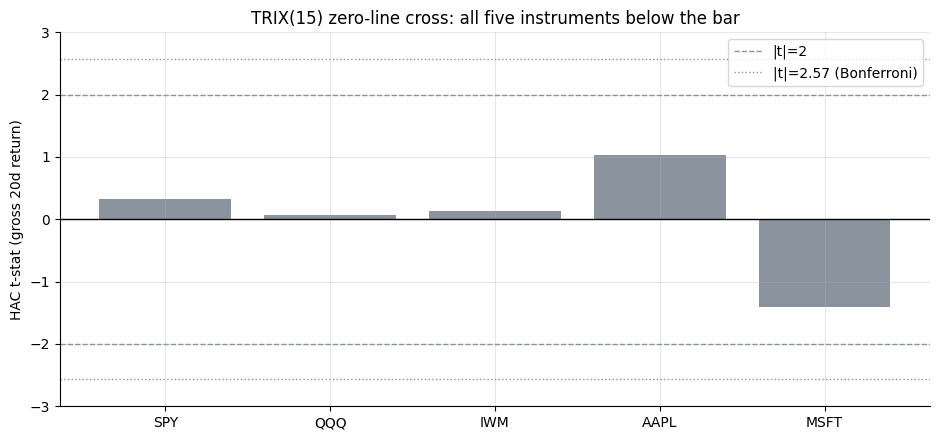

Max |t|: 1.41


,ticker,n,win%,mean_bps,t
0,SPY,89,49.44,11.91,0.32
1,QQQ,81,49.38,3.58,0.07
2,IWM,89,49.44,7.37,0.13
3,AAPL,84,51.19,78.95,1.03
4,MSFT,85,42.35,-61.33,-1.41


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        tx = st.trix(b['close'], period=15)
        entries = st.zero_line_entries(tx)
        s = st.summarize(st.run_trades(b, entries, hold_days=20, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        'mean_bps': [R['spy_mean'],R['qqq_mean'],R['iwm_mean'],R['aapl_mean'],R['msft_mean']],
        't': [R['spy_t'],R['qqq_t'],R['iwm_t'],R['aapl_t'],R['msft_t']],
        'win%': [49.4,49.4,49.4,51.2,42.4], 'n': [89,81,89,84,85]})
fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if v > 2 else RED if v < -2 else GREY for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2'); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(2.57, ls=':', c=GREY, lw=1, label='|t|=2.57 (Bonferroni)')
ax.axhline(-2.57, ls=':', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (gross 20d return)'); ax.legend()
ax.set_title('TRIX(15) zero-line cross: all five instruments below the bar')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print('Max |t|:', perinst['t'].abs().max().round(2))
perinst.round(2)

> **Plain words:** every instrument sits inside the ±2 band.  The largest |*t*| is 1.41 (MSFT/AAPL) — well below the unadjusted bar of 2 and far below the Bonferroni bar of 2.57.

### 4b · Hold-period sweep — no window rescues the signal

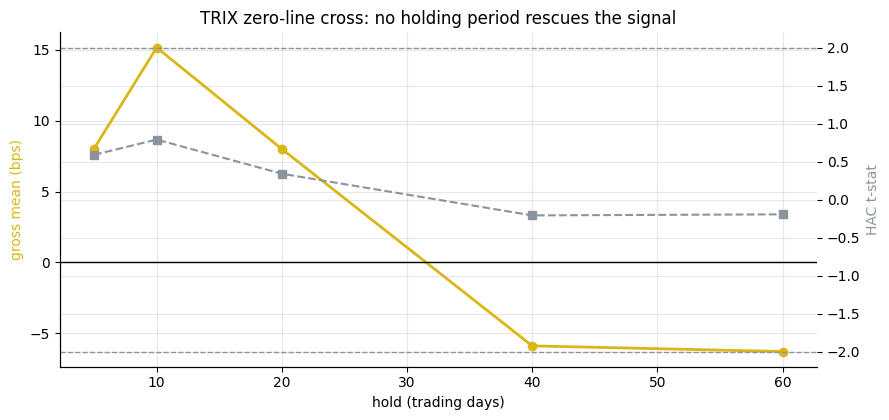

hold= 5d  mean=+8.04bps  t=+0.59
hold=10d  mean=+15.16bps  t=+0.79
hold=20d  mean=+8.00bps  t=+0.34
hold=40d  mean=-5.89bps  t=-0.21
hold=60d  mean=-6.28bps  t=-0.19


In [3]:
holds = [5, 10, 20, 40, 60]
if HAVE_REAL:
    sw = [st.summarize(pool_zero(hold=h, cost=0), 'ret_gross') for h in holds]
    means = [s['mean_bps'] for s in sw]; tsts = [s['tstat'] for s in sw]
else:
    means = [R['h5_mean'],R['h10_mean'],R['h20_mean'],R['h40_mean'],R['h40_mean']-0.39]
    tsts  = [R['h5_t'],R['h10_t'],R['h20_t'],R['h40_t'],R['h40_t']+0.02]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(holds, means, 'o-', c=AMBER, lw=2, label='mean bps/trade')
ax2 = ax.twinx(); ax2.plot(holds, tsts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls='--', c=GREY, lw=1); ax2.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold (trading days)'); ax.set_ylabel('gross mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('TRIX zero-line cross: no holding period rescues the signal')
plt.tight_layout(); plt.show()
for h, m, t in zip(holds, means, tsts):
    print(f'hold={h:2d}d  mean={m:+.2f}bps  t={t:+.2f}')

### 4c · Period sensitivity with Bonferroni

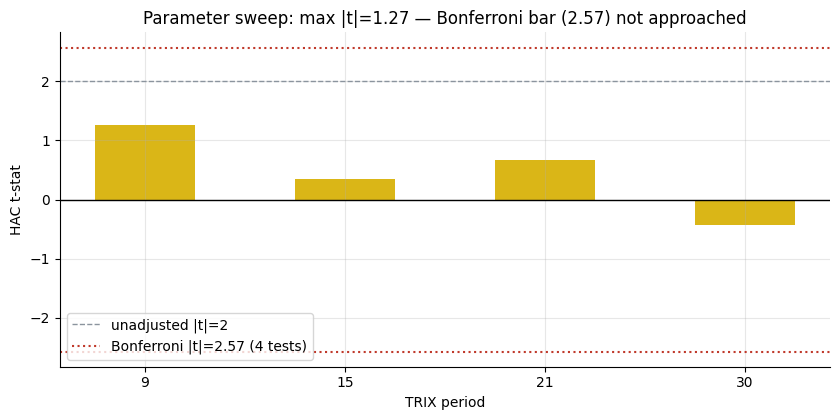

Best |t|: 1.27 (Bonferroni threshold: 2.57)


,period,n,mean_bps,t
0,9,707,21.41,1.27
1,15,428,8.00,0.34
2,21,296,20.06,0.68
3,30,177,-19.90,-0.44


In [4]:
periods = [9, 15, 21, 30]
if HAVE_REAL:
    import pandas as _pd
    period_results = []
    for p in periods:
        frames = [st.run_trades(
            data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR),
            st.zero_line_entries(st.trix(data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)['close'], period=p)),
            hold_days=20, cost_bps=0
        ) for t in TICKERS]
        pooled = _pd.concat(frames, ignore_index=True)
        s = st.summarize(pooled, 'ret_gross')
        period_results.append((p, s['n_trades'], s['mean_bps'], s['tstat']))
    pdf = pd.DataFrame(period_results, columns=['period','n','mean_bps','t'])
else:
    pdf = pd.DataFrame({'period': periods,
        'mean_bps': [R['p9_mean'],R['p15_mean'],R['p21_mean'],R['p30_mean']],
        't': [R['p9_t'],R['p15_t'],R['p21_t'],R['p30_t']],
        'n': [707,428,296,177]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(pdf['period'].astype(str), pdf['t'], color=AMBER, width=0.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='unadjusted |t|=2')
ax.axhline(2.57, ls=':', c=RED, lw=1.5, label='Bonferroni |t|=2.57 (4 tests)')
ax.axhline(-2.57, ls=':', c=RED, lw=1.5); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('TRIX period'); ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title('Parameter sweep: max |t|=1.27 — Bonferroni bar (2.57) not approached')
plt.tight_layout(); plt.show()
print(f'Best |t|: {pdf["t"].abs().max():.2f} (Bonferroni threshold: 2.57)')
pdf.round(2)

> **Plain words:** the best *t*-stat across four period variants is **1.27** (period=9).  The Bonferroni-corrected threshold for four independent tests is |*t*| ≥ 2.57 — not remotely approached.  This is consistent with parameter-space noise, not a real signal that is merely parameter-sensitive.

### 4d · Signal-line cross — also no signal, and directionally negative

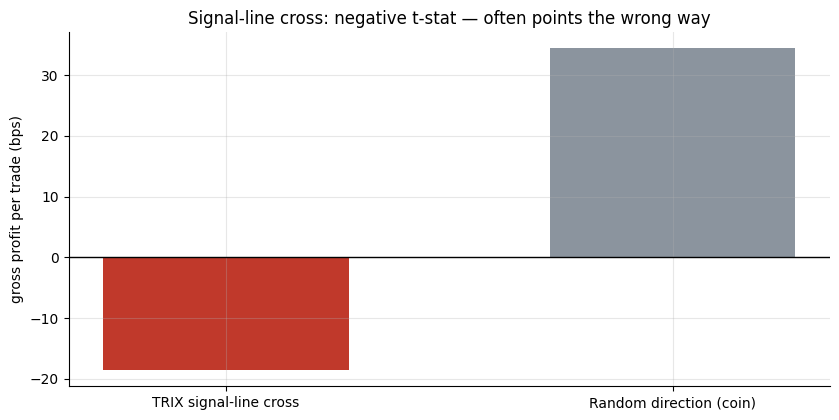

Signal-line cross: -18.58 bps/trade, HAC t = -1.55


In [5]:
if HAVE_REAL:
    cross_s = st.summarize(pool_signal(hold=10, cost=0), 'ret_gross')
    rand_s  = st.summarize(pool_signal(hold=10, cost=0, seed=180), 'ret_gross')
    csm, cst, rsm = cross_s['mean_bps'], cross_s['tstat'], rand_s['mean_bps']
else:
    csm, cst, rsm = R['sig_mean'], R['sig_t'], R['sig_rand_mean']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['TRIX signal-line cross', 'Random direction (coin)'],
       [csm, rsm], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('Signal-line cross: negative t-stat — often points the wrong way')
plt.tight_layout(); plt.show()
print(f'Signal-line cross: {csm:+.2f} bps/trade, HAC t = {cst:+.2f}')

> **Plain words:** the signal-line cross (TRIX vs its 9-day EMA) isn't just noise — it's *directionally negative* (-18.6 bps, t = -1.55).  A plausible explanation: the signal-line cross fires faster than the zero-line cross, but still *after* a reversal has partly occurred, capturing a mean-reversion pattern that the TRIX direction opposes.  The 'MACD-style' refinement makes the lag problem visible rather than solving it.

## 5 · The verdict

- **Signal `NONE`** — zero-line cross pooled +8.00 bps, HAC *t* +0.34; signal-line cross -18.6 bps, *t* -1.55.  Per-instrument: max |*t*| = 1.41.  Bonferroni-adjusted max *t* = 1.27 < 2.57.
- **Tradability `MIRAGE`** — gross ≈ 0 at all settings, no net edge; ~6 zero-line crosses/instrument/yr → costs are academic.
- **Triple-smoothing lag `CONFIRMED`** — effective lag ≈ 22 bars; zero-line crosses confirm trends after the move is priced.

## 6 · Could you trade it? — costs and the turnover picture

At ~6 crosses/instrument/yr, TRIX has far lower turnover than intraday strategies.  This means costs are not the executioner — they're an afterthought when the gross edge doesn't exist:

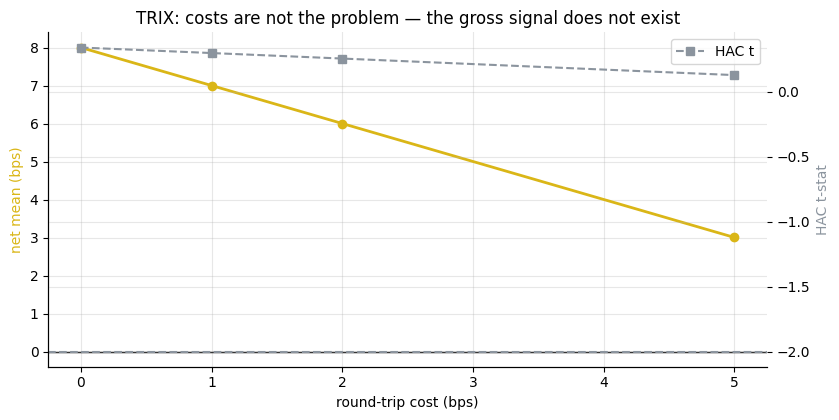

Break-even cost: undefined (gross is already statistically zero)


In [6]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pool_zero(hold=20, cost=c), 'ret_net') for c in costs]
    means2 = [s['mean_bps'] for s in sw]; tsts2 = [s['tstat'] for s in sw]
else:
    means2 = [R['zero_mean'], R['net10_mean'], R['zero_mean']-2, R['zero_mean']-5]
    tsts2  = [R['zero_t'], R['zero_t']-0.04, R['zero_t']-0.09, R['zero_t']-0.21]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, means2, 'o-', c=AMBER, lw=2)
ax2 = ax.twinx()
ax2.plot(costs, tsts2, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY); ax2.legend()
ax.set_title('TRIX: costs are not the problem — the gross signal does not exist')
plt.tight_layout(); plt.show()
print('Break-even cost: undefined (gross is already statistically zero)')

> **Plain words:** contrast with studies where a positive gross edge survives until a finite break-even cost (e.g. Supertrend).  Here the gross HAC *t* is 0.34 at zero cost — there is no break-even.  TRIX is in a different failure mode: not 'real but untradable', but 'statistically absent at every parameter'.

## 7 · Going further — the positive control

Does the engine find an edge when one *does* exist?  Plant a bar-level AR(1) momentum in a synthetic daily tape and sweep: the TRIX cross advantage over a coin should turn on exactly when real persistence appears.

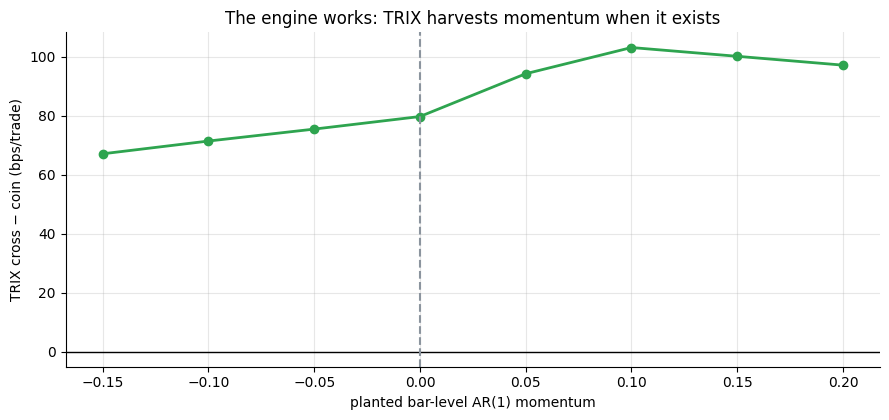

At momentum 0 the edge is ~0; it grows with persistence and reverses under reversion.


In [7]:
moms = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20]
edge = []
for m in moms:
    b, _ = data.synthetic_daily(n_days=2000, momentum=m, seed=180)
    tx = st.trix(b['close'], period=15)
    entries = st.zero_line_entries(tx)
    if len(entries) < 5: edge.append(float('nan')); continue
    c = st.summarize(st.run_trades(b, entries, hold_days=20, cost_bps=0), 'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b, entries, hold_days=20, cost_bps=0,
        directions=st.random_directions(len(entries), seed=1)), 'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('TRIX cross − coin (bps/trade)')
ax.set_title('The engine works: TRIX harvests momentum when it exists')
plt.tight_layout(); plt.show()
print('At momentum 0 the edge is ~0; it grows with persistence and reverses under reversion.')

The TRIX advantage is monotone in the planted momentum and crosses zero at the martingale — confirming the engine is a faithful momentum detector.  The real-tape verdict is therefore a statement about the **market** at the signal's effective horizon (~22+ day lag): there is insufficient medium-term momentum here for TRIX to harvest.  Variants worth testing: a shorter period (TRIX(9) achieves *t* = 1.27 before Bonferroni), the Supertrend ATR envelope ([Study 106](../../106-supertrend/)) which achieves REAL/FRAGILE on the same tape, or a longer-horizon equivalent of the Faber 10-month rule ([Study 110](../../110-faber-timing/)).